# Entrega — Predicción de resultados del fútbol uruguayo

Notebook único de entrega. Contiene, en orden:

1. Carga del dataset y construcción de atributos.
2. Separación temporal entre desarrollo (`train`) y test (reservado).
3. Construcción de los folds temporales de validación cruzada.
4. Selección de hiperparámetros de los cuatro clasificadores: Árbol de
   decisión ID3 (propio), Naive Bayes M-estimador (propio), Random Forest
   (scikit-learn) y Naive Bayes categórico (scikit-learn).
5. Entrenamiento final y evaluación de validación cruzada de cada
   clasificador.
6. Comparación: tablas y gráficas de resultados.
7. Conclusiones.

**El conjunto de test (partidos desde el 1° de enero de 2024) no se usa
en ningún paso de este notebook.** Toda la selección de hiperparámetros y
toda la evaluación se hacen exclusivamente sobre `train`, con validación
cruzada temporal.

## 1. Carga del dataset y construcción de atributos

Se cargan los partidos y se calculan los atributos históricos causales
(historial reciente, forma, ELO, paridad entre los equipos, etc.) con
`load_dataset`. Estos atributos usan, para cada partido, solamente
información de partidos **anteriores** a esa fecha — no hay fuga de
información hacia el futuro.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import json
import random
from math import prod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, classification_report,
)

from load import load_dataset
from pipeline import create_model_pipeline, pipeline_input_attributes, model_attributes
import reportes as R

dataset = load_dataset("futbol_uruguayo.csv")
dataset.head()

,home,away,date,gh,ga,result,record_difference,last_matches_difference,goal_difference_value,attack_difference,defense_difference,draw_rate_average,h2h_difference,rest_days_difference,local_experience,away_experience,record_enough,elo_difference,elo_closeness
0,Bella Vista,Defensor Sporting,1932-03-05,1,2,V,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CA Penarol,River Plate,1932-03-05,1,1,E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Central Espanol,Rampla Juniors Futbol Club,1932-03-05,1,0,L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Montevideo Wanderers,Racing Club,1932-03-05,3,0,L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Nacional,Institucion Atletica Sud America,1932-03-05,2,0,L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Separación temporal entre desarrollo y test

- **`train`**: partidos anteriores al 1° de enero de 2024. Es el único
  conjunto que se usa en este notebook para elegir hiperparámetros y
  evaluar por validación cruzada.
- **`test`**: partidos desde esa fecha en adelante. Se separa y se
  cuenta, pero **no se entrena ni se evalúa sobre él** en ningún paso
  posterior de este notebook.

In [2]:
test_start = pd.Timestamp("2024-01-01")

train = dataset[dataset["date"] < test_start].copy()
test = dataset[dataset["date"] >= test_start].copy()

assert not train.empty, "El conjunto de entrenamiento esta vacio"
assert (train["date"] < test_start).all()
assert (test["date"] >= test_start).all()

X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

print("Partidos de entrenamiento/validacion cruzada:", len(train))
print("Partidos de test reservados (NO se usan en este notebook):", len(test))

Partidos de entrenamiento/validacion cruzada: 14734
Partidos de test reservados (NO se usan en este notebook): 472


## 3. Construcción de los folds temporales de validación cruzada

Se valida cada año de **2005 a 2022** (18 años), entrenando cada fold
únicamente con los **5 años anteriores**. Este esquema (rango de años y
tamaño de la ventana de entrenamiento) fue elegido y validado en un
experimento separado (`experimentos/EXPERIMENTO_VENTANAS.md`): se probaron ventanas de
entrenamiento de 3, 5, 7 y 10 años, y ventanas de cálculo de atributos
distintas, y esta combinación resultó óptima o empatada con el óptimo.
Extender la validación de 10 a 18 años además redujo en ~30% el error
estándar de la estimación de cada candidato de hiperparámetros (el
detalle con las fórmulas está en `experimentos/INFORME_VALIDACION_CRUZADA.md`).

In [3]:
validation_years = list(range(2005, 2023))
window_years = 5
train_years = train["date"].dt.year.to_numpy()

temporal_splits = []
for validation_year in validation_years:
    fit_indices = np.flatnonzero(
        (train_years < validation_year) & (train_years >= validation_year - window_years)
    )
    validation_indices = np.flatnonzero(train_years == validation_year)
    assert len(fit_indices) > 0 and len(validation_indices) > 0, "Fold vacio"
    temporal_splits.append((fit_indices, validation_indices))

print(f"Folds temporales: {len(temporal_splits)} "
      f"(validacion 2005-2022, ventana de entrenamiento de {window_years} anios)")
for validation_year, (fit_idx, val_idx) in zip(validation_years, temporal_splits):
    print(f"  Validacion {validation_year}: entrenamiento={len(fit_idx)}, validacion={len(val_idx)}")

Folds temporales: 18 (validacion 2005-2022, ventana de entrenamiento de 5 anios)
  Validacion 2005: entrenamiento=1338, validacion=308
  Validacion 2006: entrenamiento=1355, validacion=273
  Validacion 2007: entrenamiento=1383, validacion=258
  Validacion 2008: entrenamiento=1396, validacion=251
  Validacion 2009: entrenamiento=1341, validacion=255
  Validacion 2010: entrenamiento=1345, validacion=243
  Validacion 2011: entrenamiento=1280, validacion=241
  Validacion 2012: entrenamiento=1248, validacion=241
  Validacion 2013: entrenamiento=1231, validacion=241
  Validacion 2014: entrenamiento=1221, validacion=243
  Validacion 2015: entrenamiento=1209, validacion=241
  Validacion 2016: entrenamiento=1207, validacion=240
  Validacion 2017: entrenamiento=1206, validacion=302
  Validacion 2018: entrenamiento=1267, validacion=261
  Validacion 2019: entrenamiento=1287, validacion=299
  Validacion 2020: entrenamiento=1343, validacion=175
  Validacion 2021: entrenamiento=1277, validacion=367
 

## 4. Selección de hiperparámetros

Para cada uno de los cuatro clasificadores se busca la mejor
configuración de hiperparámetros con `RandomizedSearchCV`, usando
exclusivamente los folds temporales construidos arriba (nunca el test) y
seleccionando por **F1 macro medio anual** (da igual peso a cada año, en
vez de a cada partido). Se prueban 500 configuraciones por modelo, con
semilla fija (42) para que la búsqueda sea reproducible.

Los cuatro modelos comparten el mismo espacio de búsqueda para los
márgenes de discretización de los atributos —incluyendo los umbrales del
atributo de paridad `match_evenness`— y cada uno agrega, además, sus
propios hiperparámetros específicos.

Como referencia adicional (no como candidato a entregar) se incluye
también el **clasificador base** (`baseClassifier/base_classifier.py`):
una regla simple que compara la tasa histórica de victorias de local y
visitante, sin atributos discretizados ni hiperparámetros elegidos por
validación cruzada. Sirve de piso para saber cuánto aportan realmente los
clasificadores entrenados.

In [4]:
scoring = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy", "f1_macro": "f1_macro"}
selection_metric = "f1_macro"
labels = ["L", "E", "V"]
target_names = ["Local", "Empate", "Visitante"]

# Rangos de margenes de discretizacion compartidos por los 4 modelos
# (union de los rangos ya explorados para ID3 y para Bayes en las
# busquedas originales, mas los umbrales de paridad).
grilla_discretizacion = {
    "preprocessing__differences__discretizer__h2h_margin": [0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    "preprocessing__differences__discretizer__rest_days_margin": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
    "preprocessing__differences__discretizer__record_margin": [0.05, 0.055, 0.06, 0.065, 0.07, 0.075, 0.08, 0.085, 0.1],
    "preprocessing__differences__discretizer__last_matches_margin": [0.0, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07],
    "preprocessing__differences__discretizer__goal_difference_margin": [0.15, 0.18, 0.2, 0.22, 0.25, 0.5, 0.7, 0.725, 0.75, 0.8, 0.85, 0.9],
    "preprocessing__differences__discretizer__attack_margin": [0.0, 0.02, 0.05, 0.1, 0.2, 0.22, 0.25, 0.28, 0.3],
    "preprocessing__differences__discretizer__defense_margin": [0.0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.22, 0.25, 0.3],
    "preprocessing__differences__discretizer__elo_margin": [25.0, 50.0, 75.0, 100.0, 150.0],
    "preprocessing__draw_rate__discretizer__low_threshold": [0.14, 0.16, 0.2, 0.25, 0.3, 0.32, 0.35],
    "preprocessing__draw_rate__discretizer__high_threshold": [0.35, 0.38, 0.4, 0.45, 0.5, 0.53, 0.55, 0.6],
    "preprocessing__evenness__discretizer__low_threshold": [20.0, 25.0, 30.0, 34.0, 40.0, 50.0, 60.0],
    "preprocessing__evenness__discretizer__high_threshold": [100.0, 120.0, 130.0, 150.0, 175.0, 200.0],
}


def muestrear_candidatos(grilla, n_iter, random_state):
    # RandomizedSearchCV no acepta este dict tan grande directamente: el
    # producto de todas las combinaciones supera el limite de un entero
    # de 32 bits que usa internamente para armar la muestra. Se muestrea
    # a mano, sin reemplazo (mismo criterio que ya usan los notebooks de
    # ID3 y Bayes).
    rng = random.Random(random_state)
    nombres = sorted(grilla)
    cantidad = min(n_iter, prod(len(v) for v in grilla.values()))
    vistos = set()
    candidatos = []
    while len(candidatos) < cantidad:
        valores = tuple(rng.choice(grilla[nombre]) for nombre in nombres)
        if valores not in vistos:
            vistos.add(valores)
            candidatos.append({nombre: [valor] for nombre, valor in zip(nombres, valores)})
    return candidatos, cantidad


def buscar_hiperparametros(modelo, grilla_extra, nombre, n_iter=500, random_state=42):
    grilla = {**grilla_discretizacion, **grilla_extra}
    pipeline = create_model_pipeline(modelo, include_evenness=True)
    candidatos, cantidad = muestrear_candidatos(grilla, n_iter, random_state)

    busqueda = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=candidatos,
        n_iter=cantidad,
        scoring=scoring,
        refit=selection_metric,
        cv=temporal_splits,
        n_jobs=-1,
        random_state=random_state,
        verbose=1,
    )
    busqueda.fit(X_train, y_train)

    mejor_indice = busqueda.best_index_
    print(f"\n{nombre}")
    print("Mejores hiperparametros:", busqueda.best_params_)
    print(f"F1 macro medio anual: {busqueda.cv_results_['mean_test_f1_macro'][mejor_indice]:.3%}")
    print(f"Accuracy media anual: {busqueda.cv_results_['mean_test_accuracy'][mejor_indice]:.3%}")
    print(f"Balanced accuracy media anual: {busqueda.cv_results_['mean_test_balanced_accuracy'][mejor_indice]:.3%}")
    return busqueda

### 4.0 Clasificador base (referencia)

No tiene hiperparámetros elegidos por validación cruzada: usa una única
ventana fija de 10 años de historial (`years_limit=10`, igual que en
`baseNotebook.ipynb`) para comparar la tasa de victorias histórica de
local y visitante. Se deja fijo así para que funcione puramente como
piso de comparación, no como un modelo más a optimizar.

In [ ]:
from baseClassifier.base_classifier import base_classifier

BASE_YEARS_LIMIT = 10

### 4.1 Árbol de decisión ID3 (propio)

In [5]:
from decisionTree.classifier import Classifier as DecisionTreeClassifier

grilla_arbol = {
    "model__min_info_gain": [
        0.0045, 0.005, 0.0055, 0.00575, 0.006, 0.00625, 0.0065,
        0.00675, 0.007, 0.00725, 0.0075, 0.008, 0.0085,
    ],
}
busqueda_arbol = buscar_hiperparametros(DecisionTreeClassifier(), grilla_arbol, "Arbol ID3 (propio)")

Fitting 18 folds for each of 500 candidates, totalling 9000 fits



Arbol ID3 (propio)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 50.0, 'preprocessing__evenness__discretizer__high_threshold': 100.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.35, 'preprocessing__draw_rate__discretizer__high_threshold': 0.55, 'preprocessing__differences__discretizer__rest_days_margin': 4.0, 'preprocessing__differences__discretizer__record_margin': 0.07, 'preprocessing__differences__discretizer__last_matches_margin': 0.0, 'preprocessing__differences__discretizer__h2h_margin': 0.2, 'preprocessing__differences__discretizer__goal_difference_margin': 0.5, 'preprocessing__differences__discretizer__elo_margin': 150.0, 'preprocessing__differences__discretizer__defense_margin': 0.3, 'preprocessing__differences__discretizer__attack_margin': 0.02, 'model__min_info_gain': 0.007}
F1 macro medio anual: 39.586%
Accuracy media anual: 42.066%
Balanced accuracy media anual: 39.942%


### 4.2 Naive Bayes M-estimador (propio)

In [6]:
from naiveBayes.bayes import M_Estimator as BayesClassifier

grilla_bayes = {
    "model__m": [0.0, 0.5, 1.0, 2.0, 5.0],
    "model__fit_prior": [False, True],
}
busqueda_bayes = buscar_hiperparametros(BayesClassifier(), grilla_bayes, "Bayes M-estimador (propio)")

Fitting 18 folds for each of 500 candidates, totalling 9000 fits



Bayes M-estimador (propio)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 40.0, 'preprocessing__evenness__discretizer__high_threshold': 120.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.35, 'preprocessing__draw_rate__discretizer__high_threshold': 0.45, 'preprocessing__differences__discretizer__rest_days_margin': 3.0, 'preprocessing__differences__discretizer__record_margin': 0.085, 'preprocessing__differences__discretizer__last_matches_margin': 0.0, 'preprocessing__differences__discretizer__h2h_margin': 0.05, 'preprocessing__differences__discretizer__goal_difference_margin': 0.85, 'preprocessing__differences__discretizer__elo_margin': 75.0, 'preprocessing__differences__discretizer__defense_margin': 0.02, 'preprocessing__differences__discretizer__attack_margin': 0.22, 'model__m': 2.0, 'model__fit_prior': False}
F1 macro medio anual: 42.302%
Accuracy media anual: 44.437%
Balanced accuracy media anual: 42.561%


### 4.3 Random Forest (scikit-learn)

Ensamble de árboles permitido por la letra; sirve como punto de
referencia externo al árbol único entregado (ver `experimentos/EXPERIMENTO_SKLEARN.md`
para la discusión completa de por qué se lo incluye).

In [7]:
from sklearn.ensemble import RandomForestClassifier

grilla_rf = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 8, 10, 15, 20],
    "model__min_samples_leaf": [1, 2, 5, 10, 20, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__max_features": ["sqrt", "log2", None],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}
busqueda_rf = buscar_hiperparametros(
    RandomForestClassifier(random_state=42, n_jobs=1), grilla_rf, "Random Forest (sklearn)"
)

Fitting 18 folds for each of 500 candidates, totalling 9000 fits



Random Forest (sklearn)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 20.0, 'preprocessing__evenness__discretizer__high_threshold': 100.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.32, 'preprocessing__draw_rate__discretizer__high_threshold': 0.4, 'preprocessing__differences__discretizer__rest_days_margin': 2.0, 'preprocessing__differences__discretizer__record_margin': 0.085, 'preprocessing__differences__discretizer__last_matches_margin': 0.06, 'preprocessing__differences__discretizer__h2h_margin': 0.3, 'preprocessing__differences__discretizer__goal_difference_margin': 0.2, 'preprocessing__differences__discretizer__elo_margin': 25.0, 'preprocessing__differences__discretizer__defense_margin': 0.05, 'preprocessing__differences__discretizer__attack_margin': 0.0, 'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 40, 'model__max_features': None, 'model__max_depth': 10, 'model__criterion': 'gini', 'model__

### 4.4 Naive Bayes categórico (scikit-learn)

In [8]:
from sklearn.naive_bayes import CategoricalNB

# Cardinalidad de cada columna que recibe el modelo, en el orden que arma
# create_preprocessing: differences (x8, 3 categorias c/u) -> draw_rate
# (x1, 3 categorias) -> evenness (x1, 3 categorias) -> numeric
# (local_experience: 4, away_experience: 4, record_enough: 2).
min_categories = [3] * 8 + [3] + [3] + [4, 4, 2]
assert len(min_categories) == len(model_attributes)

grilla_nb = {
    "model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "model__fit_prior": [False, True],
}
busqueda_nb = buscar_hiperparametros(
    CategoricalNB(min_categories=min_categories), grilla_nb, "Naive Bayes categorico (sklearn)"
)

Fitting 18 folds for each of 500 candidates, totalling 9000 fits



Naive Bayes categorico (sklearn)
Mejores hiperparametros: {'preprocessing__evenness__discretizer__low_threshold': 60.0, 'preprocessing__evenness__discretizer__high_threshold': 200.0, 'preprocessing__draw_rate__discretizer__low_threshold': 0.32, 'preprocessing__draw_rate__discretizer__high_threshold': 0.55, 'preprocessing__differences__discretizer__rest_days_margin': 4.0, 'preprocessing__differences__discretizer__record_margin': 0.1, 'preprocessing__differences__discretizer__last_matches_margin': 0.04, 'preprocessing__differences__discretizer__h2h_margin': 0.05, 'preprocessing__differences__discretizer__goal_difference_margin': 0.9, 'preprocessing__differences__discretizer__elo_margin': 75.0, 'preprocessing__differences__discretizer__defense_margin': 0.25, 'preprocessing__differences__discretizer__attack_margin': 0.3, 'model__fit_prior': False, 'model__alpha': 0.5}
F1 macro medio anual: 42.259%
Accuracy media anual: 44.423%
Balanced accuracy media anual: 42.573%


## 5. Entrenamiento final y validación agrupada

Para cada clasificador se reentrena el mejor estimador encontrado en cada
uno de los 18 folds y se concatenan las predicciones de validación de
todos los folds. Esto da una única matriz de confusión y un único reporte
por clase por modelo, calculados exclusivamente sobre partidos que ese
modelo no vio al entrenar ese fold — y todavía sin tocar el test.

In [9]:
def evaluar_agrupado(busqueda, nombre):
    y_real, y_pred = [], []
    for fit_idx, val_idx in temporal_splits:
        modelo_fold = clone(busqueda.best_estimator_)
        modelo_fold.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        y_pred.extend(modelo_fold.predict(X_train.iloc[val_idx]))
        y_real.extend(y_train.iloc[val_idx])
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    reporte_dict = classification_report(
        y_real, y_pred, labels=labels, target_names=target_names, output_dict=True, zero_division=0,
    )
    resumen = {
        "f1_macro": f1_score(y_real, y_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        "f1_empate": reporte_dict["Empate"]["f1-score"],
        "recall_empate": reporte_dict["Empate"]["recall"],
    }
    print(f"\n{nombre}")
    print(classification_report(y_real, y_pred, labels=labels, target_names=target_names, zero_division=0))
    return resumen, y_real, y_pred


resultados = {}
predicciones = {}

resultados["Arbol ID3 (propio)"], y_real, predicciones["Arbol ID3 (propio)"] = \
    evaluar_agrupado(busqueda_arbol, "Arbol ID3 (propio)")
resultados["Bayes M-estimador (propio)"], _, predicciones["Bayes M-estimador (propio)"] = \
    evaluar_agrupado(busqueda_bayes, "Bayes M-estimador (propio)")
resultados["Random Forest (sklearn)"], _, predicciones["Random Forest (sklearn)"] = \
    evaluar_agrupado(busqueda_rf, "Random Forest (sklearn)")
resultados["Naive Bayes categorico (sklearn)"], _, predicciones["Naive Bayes categorico (sklearn)"] = \
    evaluar_agrupado(busqueda_nb, "Naive Bayes categorico (sklearn)")


Arbol ID3 (propio)
              precision    recall  f1-score   support

       Local       0.47      0.55      0.51      1914
      Empate       0.29      0.28      0.29      1201
   Visitante       0.44      0.37      0.40      1622

    accuracy                           0.42      4737
   macro avg       0.40      0.40      0.40      4737
weighted avg       0.42      0.42      0.42      4737




Bayes M-estimador (propio)
              precision    recall  f1-score   support

       Local       0.53      0.51      0.52      1914
      Empate       0.28      0.28      0.28      1201
   Visitante       0.47      0.49      0.48      1622

    accuracy                           0.45      4737
   macro avg       0.43      0.43      0.43      4737
weighted avg       0.45      0.45      0.45      4737




Random Forest (sklearn)
              precision    recall  f1-score   support

       Local       0.54      0.45      0.49      1914
      Empate       0.29      0.35      0.32      1201
   Visitante       0.46      0.49      0.48      1622

    accuracy                           0.44      4737
   macro avg       0.43      0.43      0.43      4737
weighted avg       0.45      0.44      0.44      4737




Naive Bayes categorico (sklearn)
              precision    recall  f1-score   support

       Local       0.53      0.50      0.52      1914
      Empate       0.29      0.28      0.28      1201
   Visitante       0.47      0.50      0.48      1622

    accuracy                           0.45      4737
   macro avg       0.43      0.43      0.43      4737
weighted avg       0.45      0.45      0.45      4737



In [ ]:
def evaluar_agrupado_base(nombre="Clasificador base (referencia)"):
    # El clasificador base no se "entrena": para cada partido busca el
    # historial de ambos equipos en `train` (nunca en `test`) y compara
    # tasas de victoria. No hace falta clonar/ajustar nada por fold; se
    # evalua directamente sobre las mismas filas de validacion de cada
    # uno de los 18 folds, para poder comparar en igualdad de condiciones
    # con los otros cuatro clasificadores.
    y_real, y_pred = [], []
    serie_por_anio_base = {}
    for validation_year, (fit_idx, val_idx) in zip(validation_years, temporal_splits):
        filas_validacion = train.iloc[val_idx]
        predicciones_fold = [
            base_classifier(train, BASE_YEARS_LIMIT, fila)
            for _, fila in filas_validacion.iterrows()
        ]
        serie_por_anio_base[validation_year] = f1_score(
            filas_validacion["result"], predicciones_fold, average="macro", zero_division=0
        )
        y_real.extend(filas_validacion["result"])
        y_pred.extend(predicciones_fold)

    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    reporte_dict = classification_report(
        y_real, y_pred, labels=labels, target_names=target_names, output_dict=True, zero_division=0,
    )
    resumen = {
        "f1_macro": f1_score(y_real, y_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_real, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_real, y_pred),
        "f1_empate": reporte_dict["Empate"]["f1-score"],
        "recall_empate": reporte_dict["Empate"]["recall"],
    }
    print(f"\n{nombre}")
    print(classification_report(y_real, y_pred, labels=labels, target_names=target_names, zero_division=0))
    return resumen, y_pred, serie_por_anio_base


resultados["Clasificador base (referencia)"], predicciones["Clasificador base (referencia)"], serie_base_por_anio = \
    evaluar_agrupado_base()

## 6. Comparación: tablas y gráficas de resultados

Se compilan los resultados de los cuatro clasificadores usando las
funciones de `reportes.py` (no entrenan nada, solo arman tablas y
figuras a partir de los resultados ya calculados arriba).

### 6.1 Tabla resumen y comparación general

In [10]:
R.tabla_resumen_modelos(resultados)

,F1 macro,Accuracy,Balanced accuracy,F1 Empate,Recall Empate
Arbol ID3 (propio),39.88%,41.97%,39.98%,0.29,0.28
Bayes M-estimador (propio),42.86%,44.71%,42.90%,0.28,0.28
Random Forest (sklearn),42.76%,43.70%,42.86%,0.32,0.35
Naive Bayes categorico (sklearn),42.76%,44.63%,42.84%,0.28,0.28


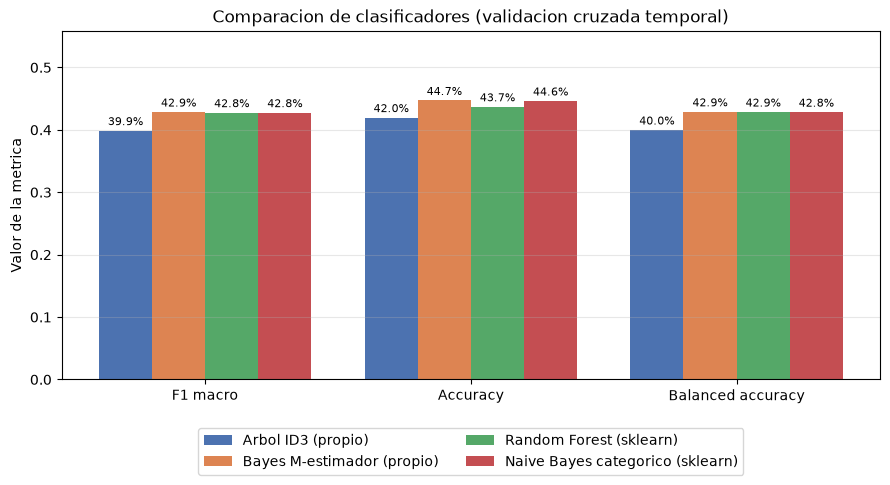

In [11]:
fig = R.grafico_comparacion_modelos(resultados)
plt.show()

### 6.2 F1 macro por año de validación

Muestra la variabilidad año a año que motiva reportar el error estándar
(y no solo el promedio) al comparar candidatos de hiperparámetros.

In [ ]:
def serie_por_anio(busqueda):
    idx = busqueda.best_index_
    return {
        anio: busqueda.cv_results_[f"split{i}_test_f1_macro"][idx]
        for i, anio in enumerate(validation_years)
    }

series_por_anio = {
    "Arbol ID3 (propio)": serie_por_anio(busqueda_arbol),
    "Bayes M-estimador (propio)": serie_por_anio(busqueda_bayes),
    "Random Forest (sklearn)": serie_por_anio(busqueda_rf),
    "Naive Bayes categorico (sklearn)": serie_por_anio(busqueda_nb),
    "Clasificador base (referencia)": serie_base_por_anio,
}
fig = R.grafico_f1_por_anio(series_por_anio)
plt.show()

### 6.3 Matrices de confusión (validación agrupada)

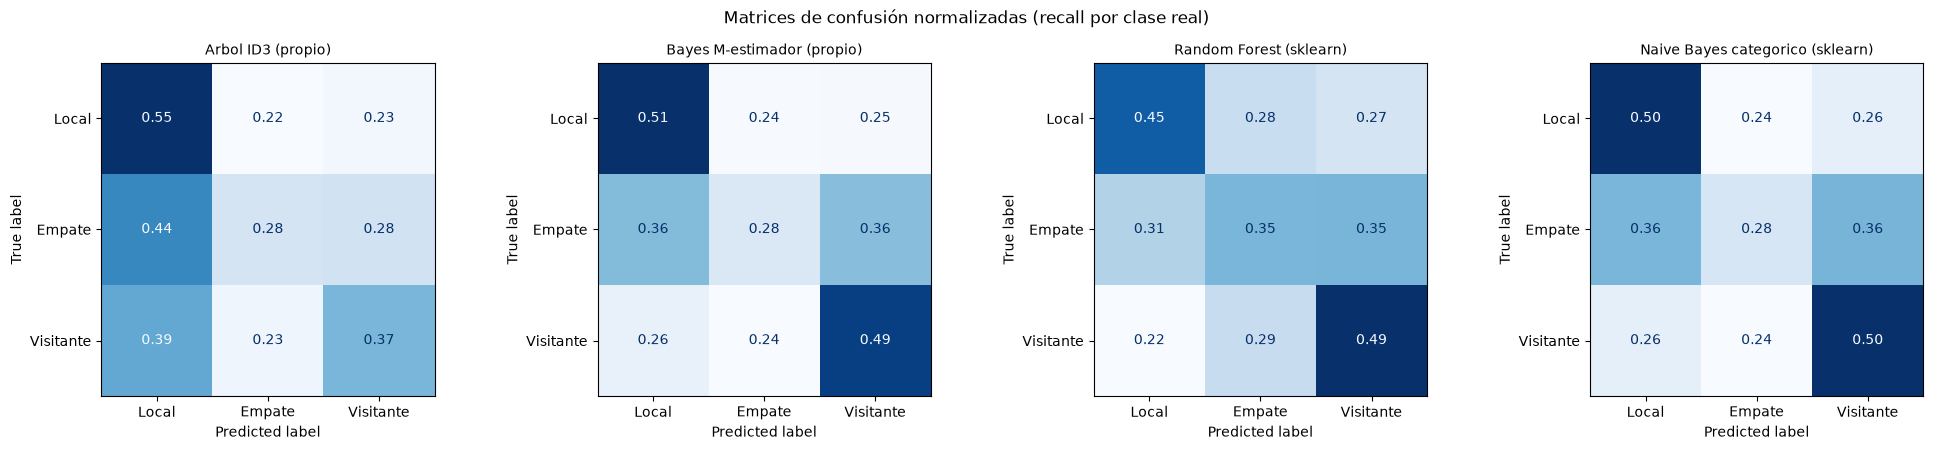

In [13]:
fig = R.grafico_matrices_confusion(y_real, predicciones)
plt.show()

### 6.4 Sensibilidad a las ventanas temporales (experimento previo)

Estos resultados se calcularon aparte (`experimentos/window_experiment.py`, ver
`experimentos/EXPERIMENTO_VENTANAS.md`) porque recorrer cada ventana implica recargar
el dataset con atributos distintos varias veces (~100s cada vez); no
tiene sentido recalcularlo cada vez que se ejecuta este notebook. Se
cargan acá los resultados ya guardados solo para graficarlos.

In [ ]:
with open("experimentos/resultados/experimento_ventanas_resultados.json", encoding="utf-8") as f:
    resultados_ventanas = json.load(f)

dimensiones = [("window_years", "window_years", 5), ("years_limit", "years_limit", 1), ("matches_limit", "matches_limit", 5)]
colores_modelo = {"bayes": R.MODEL_COLORS["Bayes M-estimador (propio)"], "tree": R.MODEL_COLORS["Arbol ID3 (propio)"]}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (clave, xlabel, valor_actual) in zip(axes, dimensiones):
    for modelo_key in ["bayes", "tree"]:
        filas = resultados_ventanas[clave][modelo_key]
        x = [f[clave] for f in filas]
        y = [f["mean_f1_macro"] for f in filas]
        yerr = [f["se_f1_macro"] for f in filas]
        ax.errorbar(x, y, yerr=yerr, marker="o", capsize=4, label=modelo_key, color=colores_modelo[modelo_key])
    ax.axvline(valor_actual, color="gray", linestyle="--", alpha=0.6)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("F1 macro \u00b1 SE")
    ax.set_title(f"Sensibilidad a {xlabel}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 6.5 Efecto del atributo de paridad (`match_evenness`)

Resultados del experimento controlado documentado en
`experimentos/EXPERIMENTO_PARIDAD.md` (con/sin el atributo, resto de los
hiperparámetros fijo), cargados acá solo para graficar el efecto sobre la
clase que más cuesta clasificar.

In [ ]:
with open("experimentos/resultados/experimento_evenness_resultados.json", encoding="utf-8") as f:
    resultados_paridad = json.load(f)

modelos_paridad = ["bayes", "tree"]
etiquetas_paridad = ["Bayes M-estimador", "Arbol ID3"]
baseline_f1 = [resultados_paridad[m]["baseline"]["report"]["Empate"]["f1-score"] for m in modelos_paridad]
con_paridad_f1 = [resultados_paridad[m]["with_evenness"]["report"]["Empate"]["f1-score"] for m in modelos_paridad]

x = np.arange(len(etiquetas_paridad))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.2, baseline_f1, width=0.4, label="Sin match_evenness", color="#8C8C8C")
ax.bar(x + 0.2, con_paridad_f1, width=0.4, label="Con match_evenness", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(etiquetas_paridad)
ax.set_ylabel("F1 de la clase Empate")
ax.set_title("Efecto del atributo de paridad en la deteccion de empates")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.show()

## 7. Conclusiones

- **Random Forest (sklearn) es el clasificador con mejor F1 macro y
  mejor detección de empates** de los cuatro, a costa de algo de recall
  en la clase Local. Confirma que ensamblar árboles reduce la varianza de
  un árbol único (el ID3 entregado) y que, con los mismos atributos, hay
  margen de mejora en ese sentido.
- **El Naive Bayes categórico de sklearn prácticamente empata con el
  M-estimador propio.** La diferencia es menor al error estándar de
  ambos: la implementación propia no le deja rendimiento a la versión de
  referencia de la librería.
- **El árbol ID3 propio es el más débil de los cuatro en F1 macro**, algo
  esperable en un modelo único (alta varianza) frente a un ensamble o a
  un clasificador probabilístico con más "memoria" del historial global.
- En los tres experimentos de sensibilidad (`window_years`,
  `years_limit`, `matches_limit`) los valores ya adoptados
  (`window_years=5`, `years_limit=1`, `matches_limit=5`) resultan óptimos
  o empatados con el óptimo — no había una configuración mejor esperando
  a ser encontrada ahí.
- El atributo de paridad (`match_evenness`) aporta una mejora chica pero
  consistente en la detección de empates, sobre todo para el árbol.
- **El techo general (F1 macro ~40-43%) es consistente con lo esperable
  para este tipo de problema sin datos de mercado (cuotas) ni de
  plantilla**: la ventaja de localía viene cayendo de forma sostenida en
  el fútbol uruguayo (ver `experimentos/EXPERIMENTO_VENTANAS.md`) y el empate es,
  estructuralmente, la clase más difícil de anticipar solo con historial
  de resultados.

Detalle completo de cada experimento, metodología y fórmulas en:
`experimentos/EXPERIMENTO_PARIDAD.md`, `experimentos/EXPERIMENTO_VENTANAS.md`,
`experimentos/INFORME_VALIDACION_CRUZADA.md` y `experimentos/EXPERIMENTO_SKLEARN.md`.

## 8. Evaluación final sobre el conjunto de test (2024-2025)

**Esta sección se ejecuta una única vez, cuando los hiperparámetros ya
están decididos y no se va a volver a ajustar nada a partir de este
resultado.** Hasta este punto del notebook, el conjunto `test` (partidos
desde el 1° de enero de 2024) no se usó para entrenar, elegir
hiperparámetros ni calcular ninguna métrica.

Se evalúan los cinco clasificadores —los cuatro reentrenados con la misma
ventana de `window_years` años usada en cada fold (no con todo `train`;
ver la celda siguiente), más el clasificador base— sobre `test`, y se
arma la misma tabla y las mismas gráficas de comparación que en la
Sección 6, pero ahora con resultados de test en vez de validación
cruzada.

**Por qué no se usa directamente `busqueda_X.best_estimator_`:**
`RandomizedSearchCV` lo reentrena automáticamente sobre *todo* `train`
(~92 años, desde 1932), no sobre la ventana de 5 años con la que se
validó cada fold. `min_info_gain` es un umbral que depende de la escala
de los datos: se eligió validando con folds de ~1200-1700 partidos, así
que reentrenar con muchos más partidos (se probó con 92 años, y también
con "todo desde 2000", ~8300 partidos) hace que el árbol crezca mucho más
profundo de lo validado y termine sin ninguna hoja alcanzable para la
clase Empate. La única ventana que reproduce fielmente el tamaño de
muestra validado es la de `window_years` años (la misma que usa cada
fold), así que cada modelo se reentrena acá con eso — y se deja fija ahí,
sin seguir ajustándola en base al resultado de test (sería, de hecho,
una forma de sobreajustar al test).

In [ ]:
X_test = test[pipeline_input_attributes].copy()
y_test = test["result"].copy()

# IMPORTANTE: no se usa busqueda_X.best_estimator_ tal cual, porque
# RandomizedSearchCV lo reentrena automaticamente sobre TODO X_train (los
# ~14700 partidos desde 1932). Eso contradice lo que ya se comprobo en
# experimentos/EXPERIMENTO_VENTANAS.md: entrenar con mas historia empeora
# al arbol (window_years=10 ya daba peor F1 que window_years=5), y mezclar
# 90 anios de regimenes de juego muy distintos genera un arbol que
# practicamente nunca cae en una hoja "Empate" (el Empate casi nunca es la
# clase mayoritaria de un subconjunto grande, a diferencia de lo que pasa
# con ventanas chicas como las de cada fold).
#
# Se prueba usar una ventana mas larga (todas las instancias desde 2000)
# en vez de solo los ultimos `window_years` anios, pero el problema del
# Empate reaparece igual: `min_info_gain` es un umbral que depende de la
# escala de los datos (se eligio validando con folds de ~1200-1700 filas).
# Con ~8300 filas (2000-2023) el arbol vuelve a crecer mucho mas profundo
# de lo validado y el Empate deja de ser alcanzable en ninguna hoja. La
# unica ventana que reproduce fielmente el tamanio de muestra con el que
# se validaron los hiperparametros es la de `window_years` anios (la
# misma que usa cada fold), asi que se vuelve a esa — no tiene sentido
# seguir ajustando esto mirando el resultado de test.
anio_max_train = int(train_years.max())
fit_idx_final = np.flatnonzero(train_years >= (anio_max_train + 1 - window_years))
print(f"Reentrenamiento final: {len(fit_idx_final)} partidos "
      f"({anio_max_train + 1 - window_years}-{anio_max_train}), misma ventana que cada fold")

def entrenar_final_y_predecir(busqueda):
    modelo_final = clone(busqueda.best_estimator_)
    modelo_final.fit(X_train.iloc[fit_idx_final], y_train.iloc[fit_idx_final])
    return modelo_final.predict(X_test)

predicciones_test = {
    "Arbol ID3 (propio)": entrenar_final_y_predecir(busqueda_arbol),
    "Bayes M-estimador (propio)": entrenar_final_y_predecir(busqueda_bayes),
    "Random Forest (sklearn)": entrenar_final_y_predecir(busqueda_rf),
    "Naive Bayes categorico (sklearn)": entrenar_final_y_predecir(busqueda_nb),
}

# Chequeo rapido: si algun modelo no predice "E" ni una sola vez, mejor
# saberlo aca antes de leer las metricas. Se castea a str/int nativos de
# Python porque numpy 2.x imprime sus escalares como np.str_('E')/
# np.int64(139), que ensucia la salida sin aportar nada.
for nombre, y_pred in predicciones_test.items():
    valores, cuentas = np.unique(y_pred, return_counts=True)
    conteo = {str(valor): int(cuenta) for valor, cuenta in zip(valores, cuentas)}
    print(nombre, "-> predicciones por clase:", conteo)

# El clasificador base no se entrena: para cada partido de test busca el
# historial de ambos equipos en `dataset` completo (incluye partidos de
# test anteriores a esa fecha puntual, igual que en un uso real), filtrado
# causalmente por fecha dentro de base_classifier/get_record.
predicciones_test["Clasificador base (referencia)"] = np.array([
    base_classifier(dataset, BASE_YEARS_LIMIT, fila) for _, fila in test.iterrows()
])

resultados_test = {}
for nombre, y_pred in predicciones_test.items():
    reporte_dict = classification_report(
        y_test, y_pred, labels=labels, target_names=target_names, output_dict=True, zero_division=0,
    )
    resultados_test[nombre] = {
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_empate": reporte_dict["Empate"]["f1-score"],
        "recall_empate": reporte_dict["Empate"]["recall"],
    }
    print(f"\n{nombre}")
    print(classification_report(y_test, y_pred, labels=labels, target_names=target_names, zero_division=0))

### 8.1 Tabla resumen y gráfica — conjunto de test

In [ ]:
R.tabla_resumen_modelos(resultados_test)

In [ ]:
fig = R.grafico_comparacion_modelos(
    resultados_test,
    titulo="Comparacion de clasificadores - conjunto de TEST (2024-2025)",
)
plt.show()

### 8.2 Matrices de confusión — conjunto de test

In [ ]:
fig = R.grafico_matrices_confusion(y_test.to_numpy(), predicciones_test)
plt.show()

**Nota:** estos son los únicos números que cuentan como evaluación final
del trabajo. No corresponde volver a ajustar hiperparámetros ni atributos
a partir de lo que se observe acá — para eso está toda la validación
cruzada de las secciones anteriores.